<a href="https://colab.research.google.com/github/Chikka-Pradhayani/ABTalks-60-Days-AI-Challenge/blob/main/Day-25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q fastapi uvicorn pytest python-dotenv numpy scikit-learn

In [2]:
import os
import sys
import json
import math
import tempfile
from pathlib import Path
from typing import List, Dict, Optional, Tuple

import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
from pathlib import Path

# Create project directories
project_dir = Path("day25_ai_assistant")
app_dir = project_dir / "app"
tests_dir = project_dir / "tests"

app_dir.mkdir(parents=True, exist_ok=True)
tests_dir.mkdir(parents=True, exist_ok=True)

# Create __init__.py files
(app_dir / "__init__.py").touch()
(tests_dir / "__init__.py").touch()

print("Project structure created successfully!")
print()
print(project_dir)
print("├── app/")
print("│   └── __init__.py")
print("├── tests/")
print("│   └── __init__.py")
print("└── notebook")

Project structure created successfully!

day25_ai_assistant
├── app/
│   └── __init__.py
├── tests/
│   └── __init__.py
└── notebook


In [4]:
config_code = '''
"""Centralized configuration for the Day 25 AI assistant."""

import os
from dotenv import load_dotenv

load_dotenv()


class Config:
    """Store application configuration values.

    Parameters:
        None.

    Returns:
        None.
    """

    CHUNK_SIZE: int = int(os.getenv("CHUNK_SIZE", "500"))
    TOP_K: int = int(os.getenv("TOP_K", "3"))
    SIMILARITY_THRESHOLD: float = float(
        os.getenv("SIMILARITY_THRESHOLD", "0.20")
    )
    MODEL_NAME: str = os.getenv("MODEL_NAME", "local-tfidf")
    MAX_QUERY_LENGTH: int = int(os.getenv("MAX_QUERY_LENGTH", "500"))
    API_KEY: str = os.getenv("API_KEY", "")
'''

config_path = app_dir / "config.py"
config_path.write_text(config_code)

print(f"Created: {config_path}")

Created: day25_ai_assistant/app/config.py


In [5]:
env_example = """# Day 25 AI Assistant Configuration

CHUNK_SIZE=500
TOP_K=3
SIMILARITY_THRESHOLD=0.20
MODEL_NAME=local-tfidf
MAX_QUERY_LENGTH=500

# Optional external API key
API_KEY=
"""

env_path = project_dir / ".env.example"
env_path.write_text(env_example)

print(f"Created: {env_path}")

Created: day25_ai_assistant/.env.example


In [6]:
validator_code = '''
"""Input validation utilities for the AI assistant."""

from typing import Tuple
from .config import Config


def validate_query(query: str) -> Tuple[bool, str]:
    """Validate a user query before processing.

    Parameters:
        query: The user's input text.

    Returns:
        A tuple containing a boolean indicating whether the query is valid
        and a message describing the validation result.
    """
    if not isinstance(query, str):
        return False, "Query must be a string."

    query = query.strip()

    if not query:
        return False, "Query cannot be empty."

    if len(query) > Config.MAX_QUERY_LENGTH:
        return False, "Query exceeds the maximum allowed length."

    return True, "Valid query."
'''

validator_path = app_dir / "validator.py"
validator_path.write_text(validator_code)

print(f"Created: {validator_path}")

Created: day25_ai_assistant/app/validator.py


In [7]:
retriever_code = '''
"""Document retrieval component for the AI assistant."""

from typing import List, Dict, Any
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from .config import Config


class Retriever:
    """Retrieve relevant documents using TF-IDF similarity.

    Parameters:
        documents: A list of document dictionaries containing text and
            optional metadata.

    Returns:
        None.
    """

    def __init__(self, documents: List[Dict[str, Any]]) -> None:
        """Initialize the retriever with documents.

        Parameters:
            documents: Documents that will be searched.

        Returns:
            None.
        """
        self.documents = documents
        self.vectorizer = TfidfVectorizer()
        self.document_vectors = self.vectorizer.fit_transform(
            [document["text"] for document in documents]
        )

    def retrieve(self, query: str) -> List[Dict[str, Any]]:
        """Retrieve the most relevant documents for a query.

        Parameters:
            query: User query used for similarity search.

        Returns:
            A list of relevant documents ordered by similarity score.
        """
        query_vector = self.vectorizer.transform([query])
        scores = cosine_similarity(
            query_vector,
            self.document_vectors
        )[0]

        ranked_indices = np.argsort(scores)[::-1]

        results: List[Dict[str, Any]] = []

        for index in ranked_indices[:Config.TOP_K]:
            score = float(scores[index])

            if score >= Config.SIMILARITY_THRESHOLD:
                result = dict(self.documents[index])
                result["score"] = score
                results.append(result)

        return results
'''

retriever_path = app_dir / "retriever.py"
retriever_path.write_text(retriever_code)

print(f"Created: {retriever_path}")

Created: day25_ai_assistant/app/retriever.py


In [8]:
prompt_code = '''
"""Prompt construction utilities for the AI assistant."""

from typing import List, Dict, Any


def build_prompt(query: str, documents: List[Dict[str, Any]]) -> str:
    """Build a grounded prompt from a query and retrieved documents.

    Parameters:
        query: The user's question.
        documents: Relevant documents retrieved from the knowledge base.

    Returns:
        A formatted prompt containing the context and user question.
    """
    context_parts: List[str] = []

    for document in documents:
        context_parts.append(document["text"])

    context = "\\n\\n".join(context_parts)

    prompt = (
        "Use only the following context to answer the question.\\n\\n"
        f"Context:\\n{context}\\n\\n"
        f"Question: {query}\\n\\n"
        "Answer:"
    )

    return prompt
'''

prompt_path = app_dir / "prompt_builder.py"
prompt_path.write_text(prompt_code)

print(f"Created: {prompt_path}")

Created: day25_ai_assistant/app/prompt_builder.py


In [9]:
pipeline_code = '''
"""RAG pipeline for the Day 25 AI assistant."""

from typing import List, Dict, Any

from .retriever import Retriever
from .prompt_builder import build_prompt
from .validator import validate_query


class RAGPipeline:
    """Coordinate validation, retrieval, and prompt construction.

    Parameters:
        retriever: Retriever instance used for document search.

    Returns:
        None.
    """

    def __init__(self, retriever: Retriever) -> None:
        """Initialize the RAG pipeline.

        Parameters:
            retriever: Configured document retriever.

        Returns:
            None.
        """
        self.retriever = retriever

    def run(self, query: str) -> Dict[str, Any]:
        """Process a user query through the RAG pipeline.

        Parameters:
            query: User's natural-language question.

        Returns:
            A dictionary containing validation status, retrieved documents,
            and the generated grounded prompt.
        """
        is_valid, message = validate_query(query)

        if not is_valid:
            return {
                "success": False,
                "message": message,
                "documents": [],
                "prompt": ""
            }

        documents = self.retriever.retrieve(query)
        prompt = build_prompt(query, documents)

        return {
            "success": True,
            "message": "Query processed successfully.",
            "documents": documents,
            "prompt": prompt
        }
'''

pipeline_path = app_dir / "rag_pipeline.py"
pipeline_path.write_text(pipeline_code)

print(f"Created: {pipeline_path}")

Created: day25_ai_assistant/app/rag_pipeline.py


In [10]:
documents = [
    {
        "id": 1,
        "text": "Python is a high-level programming language known for its simple syntax and readability.",
        "category": "Python"
    },
    {
        "id": 2,
        "text": "FastAPI is a modern Python web framework used for building high-performance APIs.",
        "category": "FastAPI"
    },
    {
        "id": 3,
        "text": "TF-IDF converts text into numerical vectors based on word importance in documents.",
        "category": "NLP"
    },
    {
        "id": 4,
        "text": "Cosine similarity measures the similarity between two vectors by calculating the cosine of their angle.",
        "category": "NLP"
    },
    {
        "id": 5,
        "text": "RAG combines information retrieval with language generation to provide answers grounded in external knowledge.",
        "category": "RAG"
    },
    {
        "id": 6,
        "text": "Pytest is a Python testing framework used to write and execute automated tests.",
        "category": "Testing"
    },
    {
        "id": 7,
        "text": "Type hints make Python code easier to understand, maintain, and analyze with development tools.",
        "category": "Python"
    },
    {
        "id": 8,
        "text": "Environment variables allow configuration values to be separated from application source code.",
        "category": "Configuration"
    }
]

print(f"Knowledge base contains {len(documents)} documents.")

Knowledge base contains 8 documents.


In [12]:
import sys
from pathlib import Path

# Add the project directory to Python's import path
project_path = Path("day25_ai_assistant").resolve()

if str(project_path) not in sys.path:
    sys.path.insert(0, str(project_path))

from app.retriever import Retriever

retriever = Retriever(documents)

print("Retriever initialized successfully.")
print(f"Number of documents: {len(retriever.documents)}")

Retriever initialized successfully.
Number of documents: 8


In [13]:
query = "What is FastAPI?"

results = retriever.retrieve(query)

print("Query:", query)
print("\nRetrieved documents:")

for result in results:
    print(
        f"ID: {result['id']} | "
        f"Score: {result['score']:.3f} | "
        f"Category: {result['category']}"
    )
    print(result["text"])
    print()

Query: What is FastAPI?

Retrieved documents:
ID: 2 | Score: 0.396 | Category: FastAPI
FastAPI is a modern Python web framework used for building high-performance APIs.



In [14]:
from app.validator import validate_query

test_queries = [
    "What is Python?",
    "",
    "   ",
    "Explain RAG."
]

for query in test_queries:
    valid, message = validate_query(query)
    print(f"Query: {query!r}")
    print(f"Valid: {valid} | Message: {message}")
    print("-" * 50)

Query: 'What is Python?'
Valid: True | Message: Valid query.
--------------------------------------------------
Query: ''
Valid: False | Message: Query cannot be empty.
--------------------------------------------------
Query: '   '
Valid: False | Message: Query cannot be empty.
--------------------------------------------------
Query: 'Explain RAG.'
Valid: True | Message: Valid query.
--------------------------------------------------


In [15]:
from app.prompt_builder import build_prompt

query = "What is RAG?"
results = retriever.retrieve(query)

prompt = build_prompt(query, results)

print(prompt)

Use only the following context to answer the question.

Context:
RAG combines information retrieval with language generation to provide answers grounded in external knowledge.

Question: What is RAG?

Answer:


In [16]:
from app.rag_pipeline import RAGPipeline

pipeline = RAGPipeline(retriever)

response = pipeline.run("What is cosine similarity?")

print("Success:", response["success"])
print("Message:", response["message"])
print("\nRetrieved Documents:")

for document in response["documents"]:
    print(f"- {document['text']}")

print("\nGenerated Prompt:")
print(response["prompt"])

Success: True
Message: Query processed successfully.

Retrieved Documents:
- Cosine similarity measures the similarity between two vectors by calculating the cosine of their angle.

Generated Prompt:
Use only the following context to answer the question.

Context:
Cosine similarity measures the similarity between two vectors by calculating the cosine of their angle.

Question: What is cosine similarity?

Answer:


In [17]:
from app.config import Config

print("Current Configuration")
print("=" * 40)

print("CHUNK_SIZE:", Config.CHUNK_SIZE)
print("TOP_K:", Config.TOP_K)
print("SIMILARITY_THRESHOLD:", Config.SIMILARITY_THRESHOLD)
print("MODEL_NAME:", Config.MODEL_NAME)
print("MAX_QUERY_LENGTH:", Config.MAX_QUERY_LENGTH)

print("\nAPI key configured:", bool(Config.API_KEY))

Current Configuration
CHUNK_SIZE: 500
TOP_K: 3
SIMILARITY_THRESHOLD: 0.2
MODEL_NAME: local-tfidf
MAX_QUERY_LENGTH: 500

API key configured: False


In [18]:
import inspect

from app.validator import validate_query
from app.retriever import Retriever
from app.prompt_builder import build_prompt
from app.rag_pipeline import RAGPipeline

components = [
    validate_query,
    Retriever.__init__,
    Retriever.retrieve,
    build_prompt,
    RAGPipeline.__init__,
    RAGPipeline.run
]

print("Type Hint and Docstring Audit")
print("=" * 50)

for component in components:
    signature = inspect.signature(component)
    has_docstring = bool(inspect.getdoc(component))

    print(f"\n{component.__qualname__}")
    print("Signature:", signature)
    print("Has docstring:", has_docstring)

Type Hint and Docstring Audit

validate_query
Signature: (query: str) -> Tuple[bool, str]
Has docstring: True

Retriever.__init__
Signature: (self, documents: List[Dict[str, Any]]) -> None
Has docstring: True

Retriever.retrieve
Signature: (self, query: str) -> List[Dict[str, Any]]
Has docstring: True

build_prompt
Signature: (query: str, documents: List[Dict[str, Any]]) -> str
Has docstring: True

RAGPipeline.__init__
Signature: (self, retriever: app.retriever.Retriever) -> None
Has docstring: True

RAGPipeline.run
Signature: (self, query: str) -> Dict[str, Any]
Has docstring: True


In [19]:
baseline_queries = [
    "What is Python?",
    "What is FastAPI?",
    "What is TF-IDF?",
    "What is cosine similarity?",
    "What is RAG?",
    "What is pytest?",
    "Why are type hints useful?",
    "What are environment variables?",
    "How does retrieval work?",
    "How does cosine similarity help retrieval?",
    "Why is FastAPI used?",
    "Why is pytest important?",
    "What does TF-IDF do?",
    "What does a RAG pipeline do?",
    "How does input validation help?"
]

baseline_results = {}

for query in baseline_queries:
    response = pipeline.run(query)

    baseline_results[query] = {
        "success": response["success"],
        "message": response["message"],
        "documents": [
            {
                "id": doc["id"],
                "text": doc["text"],
                "category": doc["category"],
                "score": round(doc["score"], 6)
            }
            for doc in response["documents"]
        ],
        "prompt": response["prompt"]
    }

print(f"Baseline created for {len(baseline_results)} queries.")

Baseline created for 15 queries.


In [20]:
tests_code = '''
"""Unit tests for the Day 25 AI assistant."""

from app.retriever import Retriever
from app.prompt_builder import build_prompt
from app.validator import validate_query


DOCUMENTS = [
    {
        "id": 1,
        "text": "Python is a programming language.",
        "category": "Python"
    },
    {
        "id": 2,
        "text": "FastAPI is a Python framework for building APIs.",
        "category": "FastAPI"
    },
    {
        "id": 3,
        "text": "Pytest is a Python testing framework.",
        "category": "Testing"
    }
]


def test_retrieve_returns_relevant_document() -> None:
    """Test that retrieve returns a relevant document."""
    retriever = Retriever(DOCUMENTS)

    results = retriever.retrieve("What is FastAPI?")

    assert len(results) > 0
    assert results[0]["category"] == "FastAPI"


def test_retrieve_returns_similarity_score() -> None:
    """Test that retrieved documents contain similarity scores."""
    retriever = Retriever(DOCUMENTS)

    results = retriever.retrieve("Python programming")

    assert len(results) > 0
    assert "score" in results[0]
    assert results[0]["score"] >= 0.0


def test_prompt_builder_contains_query() -> None:
    """Test that the prompt contains the user's query."""
    query = "What is Python?"

    prompt = build_prompt(query, DOCUMENTS[:1])

    assert query in prompt


def test_prompt_builder_contains_context() -> None:
    """Test that the prompt contains retrieved document context."""
    query = "What is FastAPI?"

    prompt = build_prompt(query, DOCUMENTS[1:2])

    assert "FastAPI is a Python framework" in prompt


def test_validator_rejects_empty_query() -> None:
    """Test that the input validator rejects an empty query."""
    valid, message = validate_query("")

    assert valid is False
    assert "empty" in message.lower()
'''

test_path = tests_dir / "test_ai_assistant.py"
test_path.write_text(tests_code)

print(f"Created: {test_path}")

Created: day25_ai_assistant/tests/test_ai_assistant.py


In [21]:
import sys
from pathlib import Path

project_path = Path("day25_ai_assistant").resolve()

if str(project_path) not in sys.path:
    sys.path.insert(0, str(project_path))

print("Python project path:", project_path)

Python project path: /content/day25_ai_assistant


In [22]:
!pytest -q day25_ai_assistant/tests/test_ai_assistant.py

.....                                                                    [100%]
5 passed in 1.99s


In [23]:
import subprocess
import sys

test_command = [
    sys.executable,
    "-m",
    "pytest",
    "-q",
    "day25_ai_assistant/tests/test_ai_assistant.py"
]

before_test = subprocess.run(
    test_command,
    capture_output=True,
    text=True
)

print(before_test.stdout)

if before_test.returncode == 0:
    print("PRE-REFACTORING TEST STATUS: PASSED")
else:
    print("PRE-REFACTORING TEST STATUS: FAILED")
    print(before_test.stderr)

.....                                                                    [100%]
5 passed in 1.33s

PRE-REFACTORING TEST STATUS: PASSED


In [24]:
retriever_code_refactored = '''
"""Document retrieval component for the AI assistant."""

from typing import List, Dict, Any

import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from .config import Config


class Retriever:
    """Retrieve relevant documents using TF-IDF similarity.

    Parameters:
        documents: A list of document dictionaries containing text
            and optional metadata.

    Returns:
        None.
    """

    def __init__(self, documents: List[Dict[str, Any]]) -> None:
        """Initialize the retriever.

        Parameters:
            documents: Documents used as the searchable knowledge base.

        Returns:
            None.
        """
        if not documents:
            raise ValueError("Documents cannot be empty.")

        if any(
            not isinstance(document, dict)
            or "text" not in document
            for document in documents
        ):
            raise ValueError(
                "Every document must be a dictionary containing 'text'."
            )

        self.documents = documents
        self.vectorizer = TfidfVectorizer()

        texts = [document["text"] for document in documents]

        self.document_vectors = self.vectorizer.fit_transform(texts)

    def retrieve(self, query: str) -> List[Dict[str, Any]]:
        """Retrieve the most relevant documents for a query.

        Parameters:
            query: User query used for similarity search.

        Returns:
            A list of relevant documents ordered by similarity score.

        Raises:
            ValueError: If the query is empty or invalid.
        """
        if not isinstance(query, str) or not query.strip():
            raise ValueError("Query must be a non-empty string.")

        try:
            query_vector = self.vectorizer.transform([query])

            scores = cosine_similarity(
                query_vector,
                self.document_vectors
            )[0]

            ranked_indices = np.argsort(scores)[::-1]

            results: List[Dict[str, Any]] = []

            for index in ranked_indices[:Config.TOP_K]:
                score = float(scores[index])

                if score >= Config.SIMILARITY_THRESHOLD:
                    result = dict(self.documents[index])
                    result["score"] = score
                    results.append(result)

            return results

        except Exception as error:
            raise RuntimeError(
                f"Document retrieval failed: {error}"
            ) from error
'''

retriever_path.write_text(retriever_code_refactored)

print("Retriever successfully refactored.")

Retriever successfully refactored.


In [25]:
prompt_code_refactored = '''
"""Prompt construction utilities for the AI assistant."""

from typing import List, Dict, Any


def build_prompt(query: str, documents: List[Dict[str, Any]]) -> str:
    """Build a grounded prompt using retrieved documents.

    Parameters:
        query: The user's question.
        documents: Documents retrieved from the knowledge base.

    Returns:
        A formatted prompt containing context and the user question.

    Raises:
        ValueError: If the query is empty.
    """
    if not isinstance(query, str) or not query.strip():
        raise ValueError("Query must be a non-empty string.")

    context_parts: List[str] = [
        document["text"]
        for document in documents
        if isinstance(document, dict) and "text" in document
    ]

    context = "\\n\\n".join(context_parts)

    return (
        "Use only the following context to answer the question.\\n\\n"
        f"Context:\\n{context}\\n\\n"
        f"Question: {query.strip()}\\n\\n"
        "Answer:"
    )
'''

prompt_path.write_text(prompt_code_refactored)

print("Prompt builder successfully refactored.")

Prompt builder successfully refactored.


In [26]:
pipeline_code_refactored = '''
"""RAG pipeline for the Day 25 AI assistant."""

from typing import Dict, Any

from .retriever import Retriever
from .prompt_builder import build_prompt
from .validator import validate_query


class RAGPipeline:
    """Coordinate validation, retrieval, and prompt construction.

    Parameters:
        retriever: Retriever instance used for document search.

    Returns:
        None.
    """

    def __init__(self, retriever: Retriever) -> None:
        """Initialize the RAG pipeline.

        Parameters:
            retriever: Configured document retriever.

        Returns:
            None.
        """
        self.retriever = retriever

    def run(self, query: str) -> Dict[str, Any]:
        """Process a user query through the RAG pipeline.

        Parameters:
            query: User's natural-language question.

        Returns:
            A dictionary containing the processing status, retrieved
            documents, and grounded prompt.
        """
        is_valid, message = validate_query(query)

        if not is_valid:
            return {
                "success": False,
                "message": message,
                "documents": [],
                "prompt": ""
            }

        try:
            documents = self.retriever.retrieve(query)
            prompt = build_prompt(query, documents)

            return {
                "success": True,
                "message": "Query processed successfully.",
                "documents": documents,
                "prompt": prompt
            }

        except Exception as error:
            return {
                "success": False,
                "message": f"Processing failed: {error}",
                "documents": [],
                "prompt": ""
            }
'''

pipeline_path.write_text(pipeline_code_refactored)

print("RAG pipeline successfully refactored.")

RAG pipeline successfully refactored.


In [27]:
import importlib

import app.config
import app.validator
import app.retriever
import app.prompt_builder
import app.rag_pipeline

importlib.reload(app.config)
importlib.reload(app.validator)
importlib.reload(app.retriever)
importlib.reload(app.prompt_builder)
importlib.reload(app.rag_pipeline)

from app.retriever import Retriever
from app.rag_pipeline import RAGPipeline

# Recreate objects using the refactored classes
retriever = Retriever(documents)
pipeline = RAGPipeline(retriever)

print("Refactored modules loaded successfully.")

Refactored modules loaded successfully.


In [28]:
import subprocess
import sys

test_command = [
    sys.executable,
    "-m",
    "pytest",
    "-q",
    "day25_ai_assistant/tests/test_ai_assistant.py"
]

after_test = subprocess.run(
    test_command,
    capture_output=True,
    text=True
)

print(after_test.stdout)

if after_test.returncode == 0:
    print("POST-REFACTORING TEST STATUS: PASSED")
else:
    print("POST-REFACTORING TEST STATUS: FAILED")
    print(after_test.stderr)

.....                                                                    [100%]
5 passed in 1.38s

POST-REFACTORING TEST STATUS: PASSED


In [29]:
from IPython.display import Image, display
from pathlib import Path

architecture = r"""
digraph G {
    rankdir=TB;
    graph [
        label="Day 25 - AI Assistant Complete Architecture",
        labelloc="t",
        fontsize=20,
        fontname="Arial"
    ];

    node [
        shape=box,
        style="rounded",
        fontname="Arial",
        fontsize=11
    ];

    edge [
        fontname="Arial",
        fontsize=9
    ];

    user [label="User Query"];

    validator [
        label="Input Validator\nvalidate_query()"
    ];

    retriever [
        label="Retriever\nTF-IDF Vectorizer\nCosine Similarity"
    ];

    knowledge [
        label="Knowledge Base\n8 Documents"
    ];

    prompt [
        label="Prompt Builder\nbuild_prompt()"
    ];

    pipeline [
        label="RAG Pipeline\nRAGPipeline.run()"
    ];

    response [
        label="Grounded Prompt /\nAssistant Response"
    ];

    config [
        label="config.py\n• CHUNK_SIZE\n• TOP_K\n• SIMILARITY_THRESHOLD\n• MODEL_NAME\n• MAX_QUERY_LENGTH\n• API_KEY"
    ];

    env [
        label=".env / Environment Variables"
    ];

    dependencies [
        label="External / Software Dependencies\nPython • NumPy • scikit-learn\npython-dotenv • FastAPI • pytest"
    ];

    tests [
        label="pytest Tests\n5 Unit Tests"
    ];

    user -> validator [label="query"];
    validator -> retriever [label="valid query"];
    knowledge -> retriever [label="documents"];
    retriever -> prompt [label="top-k relevant documents"];
    validator -> pipeline [label="validated input"];
    retriever -> pipeline [label="retrieved documents"];
    prompt -> pipeline [label="grounded prompt"];
    pipeline -> response [label="processed result"];

    env -> config [label="configuration"];
    config -> retriever [label="TOP_K / threshold"];
    config -> validator [label="max query length"];

    tests -> validator [style=dashed, label="tests"];
    tests -> retriever [style=dashed, label="tests"];
    tests -> prompt [style=dashed, label="tests"];

    dependencies -> retriever [style=dotted];
    dependencies -> pipeline [style=dotted];
    dependencies -> tests [style=dotted];
}
"""

dot_path = Path("day25_ai_assistant/architecture.dot")
dot_path.write_text(architecture)

print("Architecture definition created:")
print(dot_path)

Architecture definition created:
day25_ai_assistant/architecture.dot


Architecture diagram generated successfully.


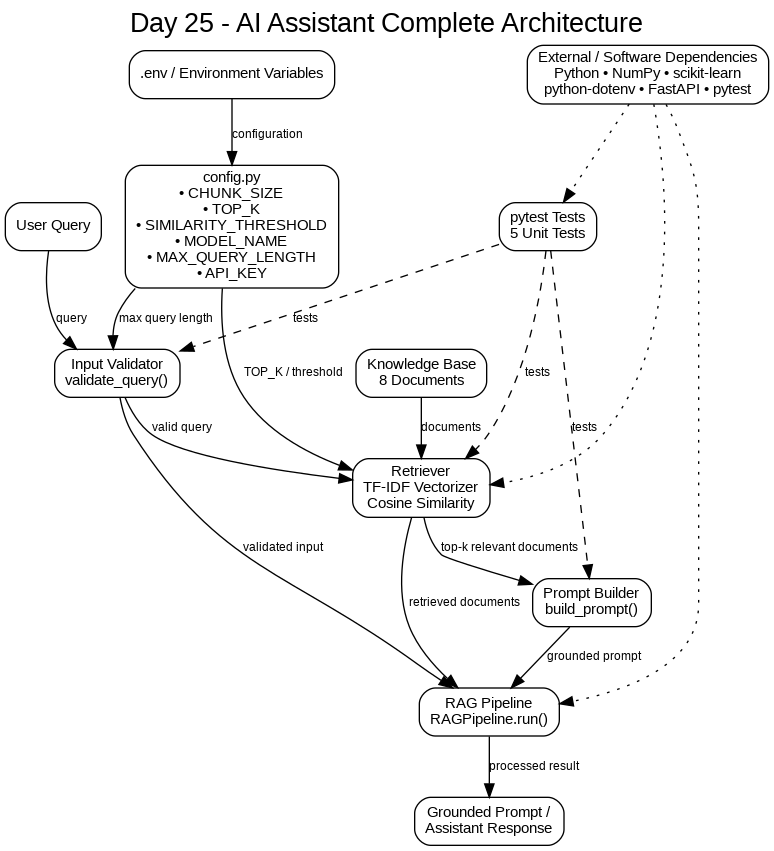

In [30]:
import subprocess
from IPython.display import Image, display

png_path = "day25_ai_assistant/architecture.png"

result = subprocess.run(
    ["dot", "-Tpng", str(dot_path), "-o", png_path],
    capture_output=True,
    text=True
)

if result.returncode != 0:
    print("Graphviz rendering failed.")
    print(result.stderr)
else:
    print("Architecture diagram generated successfully.")
    display(Image(filename=png_path))

In [31]:
refactored_results = {}

for query in baseline_queries:
    response = pipeline.run(query)

    refactored_results[query] = {
        "success": response["success"],
        "message": response["message"],
        "documents": [
            {
                "id": doc["id"],
                "text": doc["text"],
                "category": doc["category"],
                "score": round(doc["score"], 6)
            }
            for doc in response["documents"]
        ],
        "prompt": response["prompt"]
    }

print(f"Refactored system tested on {len(refactored_results)} queries.")

Refactored system tested on 15 queries.


In [32]:
identical_queries = []
different_queries = []

for query in baseline_queries:
    if baseline_results[query] == refactored_results[query]:
        identical_queries.append(query)
    else:
        different_queries.append(query)

print("=" * 60)
print("15-QUERY REGRESSION TEST")
print("=" * 60)

print(f"Total queries: {len(baseline_queries)}")
print(f"Identical outputs: {len(identical_queries)}")
print(f"Different outputs: {len(different_queries)}")

if not different_queries:
    print("\nREGRESSION TEST: PASSED")
    print("15/15 outputs are identical.")
else:
    print("\nREGRESSION TEST: FAILED")
    print("\nQueries with changed outputs:")

    for query in different_queries:
        print("-", query)

15-QUERY REGRESSION TEST
Total queries: 15
Identical outputs: 15
Different outputs: 0

REGRESSION TEST: PASSED
15/15 outputs are identical.
